# Phase 2: Segmentation via Clustering

Home Credit Default Risk, KDD Phase 2.

What this notebook does:
1. Reduce dimensions with PCA so distance behaves well, then run K-Means and hierarchical clustering in that space.
2. Pick the number of segments K using the elbow method and the silhouette score.
3. Run DBSCAN in a UMAP space to find density pockets and outliers.
4. Profile each cluster, give it a business name, and save the naming so later phases can read it.

Input: `datasets/final/features_clustering.csv` (the output of Phase 1).

Outputs land in `results/phase2_clustering/`: the PCA variance table and plot, the K-selection table and elbow plot, cluster labels, the cluster scatter and dendrogram images, the cluster profiles, and `cluster_names.csv`. The written report lives in the project-root `REPORT.md`, not in this notebook.

## 1. Setup and load data

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors
import umap   # DBSCAN dijalankan di ruang UMAP (lihat Seksi 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
INPUT_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
OUT_DIR = PROJECT_ROOT / 'results/phase2_clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
K_OPTIMAL = 5
N_PCA_CLUSTER = 10   # practical ceiling for a distance-based method

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir  : {OUT_DIR}')

df = pd.read_csv(INPUT_PATH)
print(f'\nLoaded features_clustering: {df.shape[0]:,} rows x {df.shape[1]:,} cols')
df.head()

Project root: C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk
Output dir  : C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering



Loaded features_clustering: 356,255 rows x 48 cols


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TERM_MONTHS,YEARS_BIRTH,YEARS_EMPLOYED,FLAG_SENTINEL_EMPLOYED,...,POS_MONTHS_COUNT,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_AMT_BALANCE_MEAN,CC_MONTHS_COUNT,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE_FREQ,ORGANIZATION_TYPE_FREQ,DEF_30_CNT_SOCIAL_CIRCLE_BIN
0,100002,0.634910,-0.187374,0.066332,-0.701787,-0.629424,-0.583748,-1.509648,-0.574687,0,...,-0.366144,-0.406981,-0.468517,-0.049789,-0.307651,-0.436654,-0.586459,0.945510,1.371072,4.626593
1,100003,1.236695,1.428692,0.738721,0.355520,-0.521112,1.956267,0.166044,-0.335664,0,...,-0.002970,-0.406981,-0.468517,-0.049789,-0.307651,-0.436654,1.695881,-1.717301,-0.887960,-0.338687
2,100004,-1.663200,-1.726999,-2.302035,-0.704785,-0.861917,-0.129145,0.689353,-0.753412,0,...,-0.971434,-0.406981,-0.468517,-0.049789,-0.307651,-0.436654,-0.586459,0.945510,-0.872715,-0.338687
3,100006,-0.213256,-0.554125,0.402026,-0.584662,0.406449,-1.345289,0.679947,0.467295,0,...,-0.285438,-0.406981,-0.468517,-0.049789,-0.307651,-0.193611,-0.586459,0.945510,1.371072,-0.338687
4,100007,-0.433653,0.137228,-0.156247,0.139516,-0.016026,0.315530,0.892620,0.466862,0,...,1.530432,-0.406981,-0.468517,-0.049789,-0.307651,-0.436654,-0.586459,0.945510,-1.245204,-0.338687


## 2. Reducing dimensions before clustering

K-Means and hierarchical both judge similarity by Euclidean distance, and distance loses meaning in high dimensions: with 47 features almost every applicant feels equally far from every other. PCA compresses the 47 features into a handful of components that hold most of the variation, so clustering works in a much cleaner space.

We use 10 components, the practical ceiling for a distance-based method on this kind of data. Beyond that point, adding more components buys very little additional signal for the cost of a noisier, less compact space: on the scree plot each further component contributes only a sliver of variance, so ten strikes the balance between keeping as much real structure as reasonable and staying tight enough that Euclidean distance still means something.

One thing to note: PCA is used for K-Means and hierarchical, both of which are variance-based. DBSCAN is handled differently in Section 5 because it works on density, not variance.

In [2]:
feature_cols = [c for c in df.columns if c != 'SK_ID_CURR']
X = df[feature_cols].values.astype(np.float32)
print(f'Feature matrix X: {X.shape}')

pca_full = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_SEED)
X_pca50 = pca_full.fit_transform(X)

cumvar = pca_full.explained_variance_ratio_.cumsum()
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
print(f'\nComponents for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'\nUsed for K-Means and hierarchical: PC1-PC{N_PCA_CLUSTER} ({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance)')
evr = pca_full.explained_variance_ratio_
drop_next = (evr[N_PCA_CLUSTER-1] - evr[N_PCA_CLUSTER]) * 100
print(f'  Reason for {N_PCA_CLUSTER} components: they retain {cumvar[N_PCA_CLUSTER-1]*100:.1f}% of the '
      f'variance while keeping the space compact enough for Euclidean distance to stay meaningful; '
      f'component {N_PCA_CLUSTER+1} would add only {drop_next:.2f} more points of variance.')

X_cluster = X_pca50[:, :N_PCA_CLUSTER]
X_2d = X_pca50[:, :2]

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumvar,
})
variance_df.to_csv(OUT_DIR / 'pca_variance.csv', index=False)
print(f'\nSaved {OUT_DIR / "pca_variance.csv"}')

Feature matrix X: (356255, 47)



Components for 80% variance: 22
Components for 90% variance: 28

Used for K-Means and hierarchical: PC1-PC10 (52.1% variance)
  Reason for 10 components: they retain 52.1% of the variance while keeping the space compact enough for Euclidean distance to stay meaningful; component 11 would add only 0.06 more points of variance.

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\pca_variance.csv


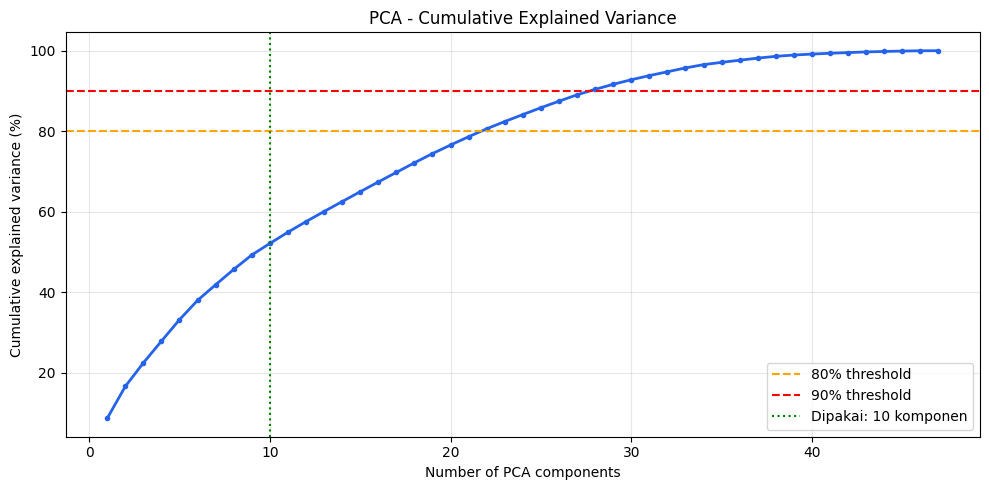

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar*100, marker='o', markersize=3, linewidth=2, color='#2563EB')
ax.axhline(80, color='orange', ls='--', label='80% threshold')
ax.axhline(90, color='red', ls='--', label='90% threshold')
ax.axvline(N_PCA_CLUSTER, color='green', ls=':', label=f'Dipakai: {N_PCA_CLUSTER} komponen')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA - Cumulative Explained Variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_variance_plot.png', dpi=150)
plt.show()

## 3. Choosing K with the elbow and the silhouette

We try K from 2 to 10 on a 30K sample, because the silhouette score is O(n squared) and too costly on the full data.

The elbow looks for the point where the drop in inertia starts to flatten. The silhouette measures how well separated the clusters are, on a scale from -1 to 1, where higher means cleaner separation.

In [4]:
K_RANGE = range(2, 11)
SAMPLE_SIZE = 30000
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_cluster), size=SAMPLE_SIZE, replace=False)
X_sample = X_cluster[sample_idx]

k_results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=RANDOM_SEED)
    k_results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil, 'time_s': round(time.time()-t0, 2)})
    print(f'  K={k:2d} | inertia={km.inertia_:12.1f} | silhouette={sil:.4f} | {time.time()-t0:.1f}s')

k_df = pd.DataFrame(k_results)
k_df.to_csv(OUT_DIR / 'k_selection.csv', index=False)
k_df

  K= 2 | inertia=    547654.4 | silhouette=0.2363 | 3.9s


  K= 3 | inertia=    491175.9 | silhouette=0.1425 | 0.6s


  K= 4 | inertia=    454447.7 | silhouette=0.1463 | 0.8s


  K= 5 | inertia=    420854.1 | silhouette=0.1466 | 0.7s


  K= 6 | inertia=    397544.4 | silhouette=0.1342 | 0.9s


  K= 7 | inertia=    377904.0 | silhouette=0.1254 | 0.9s


  K= 8 | inertia=    357492.7 | silhouette=0.1275 | 0.9s


  K= 9 | inertia=    345704.6 | silhouette=0.1227 | 1.0s


  K=10 | inertia=    335351.6 | silhouette=0.1208 | 1.1s


,k,inertia,silhouette,time_s
0,2,547654.43750,0.236327,3.86
1,3,491175.87500,0.142460,0.64
2,4,454447.68750,0.146284,0.80
3,5,420854.12500,0.146569,0.70
4,6,397544.43750,0.134227,0.90
5,7,377903.96875,0.125434,0.87
6,8,357492.68750,0.127549,0.94
7,9,345704.59375,0.122707,1.03
8,10,335351.56250,0.120752,1.10


Elbow Method     -> K = 5
Silhouette Score -> K = 2

Keputusan: K = 5
  Alasan: Elbow merekomendasi 5; silhouette puncak di 2 (biasanya K=2)
  K=5 gives a more granular and interpretable business segmentation.


C:\Users\mario\AppData\Local\Temp\ipykernel_39604\928783883.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = [np.abs(np.cross(p2-p1, p1-np.array([i, v])))/np.linalg.norm(p2-p1) for i, v in enumerate(inertias)]


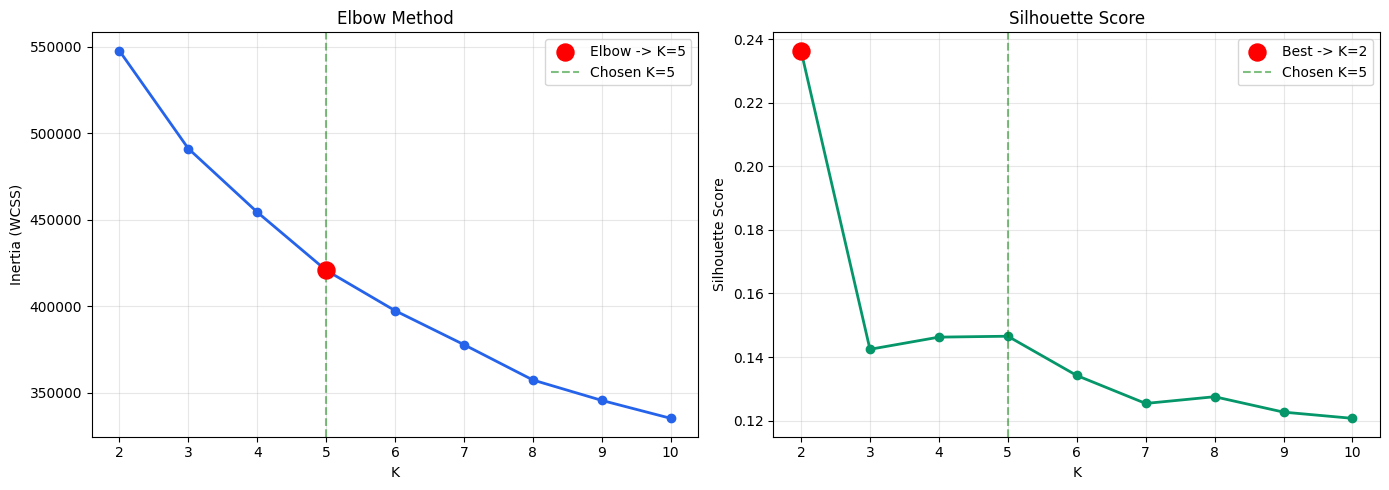

In [5]:
inertias = k_df['inertia'].values
p1 = np.array([0, inertias[0]])
p2 = np.array([len(inertias)-1, inertias[-1]])
dists = [np.abs(np.cross(p2-p1, p1-np.array([i, v])))/np.linalg.norm(p2-p1) for i, v in enumerate(inertias)]
elbow_k = int(k_df.iloc[int(np.argmax(dists))]['k'])
best_sil_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
print(f'Elbow Method     -> K = {elbow_k}')
print(f'Silhouette Score -> K = {best_sil_k}')
print(f'\nKeputusan: K = {K_OPTIMAL}')
print(f'  Alasan: Elbow merekomendasi {elbow_k}; silhouette puncak di {best_sil_k} (biasanya K=2)')
print(f'  K=5 gives a more granular and interpretable business segmentation.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_df['k'], k_df['inertia'], 'o-', color='#2563EB', linewidth=2)
axes[0].scatter([elbow_k], [k_df[k_df['k']==elbow_k]['inertia'].values[0]], s=150, color='red', zorder=5, label=f'Elbow -> K={elbow_k}')
axes[0].axvline(K_OPTIMAL, color='green', ls='--', alpha=0.5, label=f'Chosen K={K_OPTIMAL}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(k_df['k'], k_df['silhouette'], 'o-', color='#059669', linewidth=2)
axes[1].scatter([best_sil_k], [k_df[k_df['k']==best_sil_k]['silhouette'].values[0]], s=150, color='red', zorder=5, label=f'Best -> K={best_sil_k}')
axes[1].axvline(K_OPTIMAL, color='green', ls='--', alpha=0.5, label=f'Chosen K={K_OPTIMAL}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'elbow_plot.png', dpi=150)
plt.show()

## 4. K-Means on all 356K applicants

In [6]:
print('Running K-Means (K=5) on full data ...')
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s | Inertia = {kmeans.inertia_:.1f}')

rng2 = np.random.default_rng(RANDOM_SEED)
sil_idx = rng2.choice(len(X_cluster), size=10000, replace=False)
sil_kmeans = silhouette_score(X_cluster[sil_idx], kmeans_labels[sil_idx])
print(f'  Silhouette Score (sample 10K): {sil_kmeans:.4f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f'\nDistribusi cluster K-Means:')
for cid, cnt in zip(unique, counts):
    pct = cnt/len(kmeans_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} rows ({pct:5.1f}%) {"█"*int(pct/2)}')

Running K-Means (K=5) on full data ...


  Done in 3.3s | Inertia = 5199206.0


  Silhouette Score (sample 10K): 0.1468

Distribusi cluster K-Means:
  Cluster 0:   3,582 rows (  1.0%) 
  Cluster 1: 125,071 rows ( 35.1%) █████████████████
  Cluster 2:  46,905 rows ( 13.2%) ██████
  Cluster 3:  54,215 rows ( 15.2%) ███████
  Cluster 4: 126,482 rows ( 35.5%) █████████████████


## 5. DBSCAN for outliers, in UMAP space (not PCA)

DBSCAN does not group by distance to a centre the way K-Means does. It works on density: points sitting in a crowded area form a group, and a point standing alone in an empty area is marked as noise. Because of that, the result depends heavily on the shape of the space it runs in.

This is where PCA falls short. PCA only preserves linear variance and tends to flatten dense clumps, so DBSCAN in PCA space often sees one large mass with no structure. UMAP maps the non-linear shape of the data while keeping local density: tight clumps stay tight, and genuinely different applicants get pushed to the edge. So the split of duties is clear: PCA for the variance-based methods (K-Means and hierarchical), UMAP for the density-based one (DBSCAN).

The neighbourhood radius `eps` is not guessed by hand. It is picked automatically from the knee of the k-distance curve, the standard DBSCAN heuristic (Ester et al., 1996), the same elbow trick used to choose K. Points that fall into no dense region become outlier candidates that pass on to Phase 4.

In [7]:
# DBSCAN runs in UMAP space, not PCA (see the note above).
DBSCAN_SAMPLE = 50000
MIN_SAMPLES = 15

rng3 = np.random.default_rng(RANDOM_SEED)
dbscan_idx = rng3.choice(len(X), size=DBSCAN_SAMPLE, replace=False)
X_db_raw = X[dbscan_idx]   # 47 fitur asli terstandardisasi, bukan hasil PCA

print(f'Step 1 - UMAP embedding {DBSCAN_SAMPLE:,} x {X_db_raw.shape[1]} features -> 2D ...')
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0,
                    metric='euclidean', random_state=RANDOM_SEED)
X_umap = reducer.fit_transform(X_db_raw)
print(f'  Done in {time.time()-t0:.1f}s | rentang UMAP-1 [{X_umap[:,0].min():.1f}, {X_umap[:,0].max():.1f}]')

# eps chosen automatically: the knee of the k-distance curve (classic Ester et al. 1996 heuristic).
# Same trick as the K-Means elbow: the farthest distance
# from each point on the sorted curve to the line joining its two ends.
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_umap)
kdist = np.sort(nn.kneighbors(X_umap)[0][:, -1])
xx = np.arange(len(kdist))
p1 = np.array([0.0, kdist[0]]); p2 = np.array([len(kdist) - 1.0, kdist[-1]])
chord = p2 - p1
dline = np.abs(np.cross(chord, p1 - np.column_stack([xx, kdist]))) / np.linalg.norm(chord)
EPS = float(round(kdist[int(np.argmax(dline))], 3))
print(f'  eps otomatis (knee k-distance, k={MIN_SAMPLES}) = {EPS}')

print(f'Step 2 - DBSCAN in UMAP space (eps={EPS}, min_samples={MIN_SAMPLES}) ...')
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_umap)
print(f'  Done in {time.time()-t0:.1f}s')

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = int(np.sum(dbscan_labels == -1))
pct_out = n_outliers / len(dbscan_labels) * 100
print(f'  Density pockets found: {n_clusters_db}')
print(f'  Outliers / noise (label -1): {n_outliers:,} ({pct_out:.1f}%)')

u_db, c_db = np.unique(dbscan_labels, return_counts=True)
for lbl, cnt in zip(u_db, c_db):
    name = 'OUTLIER/NOISE' if lbl == -1 else f'Cluster {lbl}'
    pct = cnt / len(dbscan_labels) * 100
    print(f'  {name:20s}: {cnt:>6,} ({pct:5.1f}%)')

Step 1 - UMAP embedding 50,000 x 47 features -> 2D ...


C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 116.9s | rentang UMAP-1 [-9.0, 9.6]


C:\Users\mario\AppData\Local\Temp\ipykernel_39604\1271527644.py:24: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dline = np.abs(np.cross(chord, p1 - np.column_stack([xx, kdist]))) / np.linalg.norm(chord)


  eps otomatis (knee k-distance, k=15) = 0.097
Step 2 - DBSCAN in UMAP space (eps=0.097, min_samples=15) ...


  Done in 0.5s
  Density pockets found: 30
  Outliers / noise (label -1): 1,085 (2.2%)
  OUTLIER/NOISE       :  1,085 (  2.2%)
  Cluster 0           :  5,752 ( 11.5%)
  Cluster 1           :     65 (  0.1%)
  Cluster 2           : 21,011 ( 42.0%)
  Cluster 3           :  7,554 ( 15.1%)
  Cluster 4           :    999 (  2.0%)
  Cluster 5           :  4,820 (  9.6%)
  Cluster 6           :  3,100 (  6.2%)
  Cluster 7           :     77 (  0.2%)
  Cluster 8           :  1,636 (  3.3%)
  Cluster 9           :    468 (  0.9%)
  Cluster 10          :    322 (  0.6%)
  Cluster 11          :    454 (  0.9%)
  Cluster 12          :    115 (  0.2%)
  Cluster 13          :    392 (  0.8%)
  Cluster 14          :     72 (  0.1%)
  Cluster 15          :    138 (  0.3%)
  Cluster 16          :    323 (  0.6%)
  Cluster 17          :     42 (  0.1%)
  Cluster 18          :  1,185 (  2.4%)
  Cluster 19          :    152 (  0.3%)
  Cluster 20          :     44 (  0.1%)
  Cluster 21          :     39 ( 

## 6. Hierarchical clustering: a second way to check the segments

Hierarchical clustering builds the data up like a family tree: the most similar applicants merge first, then small groups merge into larger ones. Its way of thinking is completely different from K-Means, so if the two produce similar groupings we can be more confident the segments are real and not an artefact of one method.

The pure version needs O(n squared) memory, which is impossible for 356 thousand rows. So we run Ward on a representative sample to find five groups, compute the centre of each group, then assign every applicant to the nearest centre. This keeps the real density of the data, unlike the earlier micro-centroid approach that collapsed almost everyone into a single blob.

In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

# A genuinely meaningful Ward hierarchical clustering on 356K rows.
# Pure AgglomerativeClustering needs O(n^2) memory (impossible at 356K), so:
#   1) Ward on a representative SAMPLE (it keeps the real density of the data,
#      not the unweighted micro-centroids that once piled 94% into one cluster),
#   2) compute the centre of each cluster, then
#   3) assign ALL rows to the nearest hierarchical centre.
HIER_SAMPLE = 10000
rng_h = np.random.default_rng(RANDOM_SEED)
hidx = rng_h.choice(len(X_cluster), size=HIER_SAMPLE, replace=False)
X_h = X_cluster[hidx]

print(f'Step 1 - Ward agglomerative on a sample of {HIER_SAMPLE:,} ...')
t0 = time.time()
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
sample_labels = agglo.fit_predict(X_h)
print(f'  Done in {time.time()-t0:.1f}s')

# Centre of each cluster in PCA space
centroids = np.vstack([X_h[sample_labels == c].mean(axis=0) for c in range(K_OPTIMAL)])

print('Step 2 - Assign all rows to the nearest hierarchical centre ...')
t0 = time.time()
hier_labels = cdist(X_cluster, centroids).argmin(axis=1).astype(np.int32)
print(f'  Done in {time.time()-t0:.1f}s')

# Linkage for the dendrogram (3 methods) on a small plottable sub-sample
DENDRO_N = 2000
didx = rng_h.choice(len(X_h), size=min(DENDRO_N, len(X_h)), replace=False)
subcenters = X_h[didx]
print(f'Step 3 - Linkage (ward, complete, average) for the dendrogram on {len(subcenters)} titik ...')
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {}
for method in linkage_methods:
    t0 = time.time()
    linkage_results[method] = linkage(subcenters, method=method)
    print(f'  {method:8s}: {time.time()-t0:.1f}s')

u_h, c_h = np.unique(hier_labels, return_counts=True)
print(f'\nHierarchical cluster distribution:')
for cid, cnt in zip(u_h, c_h):
    pct = cnt / len(hier_labels) * 100
    print(f'  Cluster {cid}: {cnt:>7,} rows ({pct:5.1f}%) {"#" * int(pct/2)}')

Step 1 - Ward agglomerative on a sample of 10,000 ...


  Done in 8.2s
Step 2 - Assign all rows to the nearest hierarchical centre ...
  Done in 0.1s
Step 3 - Linkage (ward, complete, average) for the dendrogram on 2000 titik ...


  ward    : 0.1s
  complete: 0.2s


  average : 0.2s

Hierarchical cluster distribution:
  Cluster 0:   6,577 rows (  1.8%) 
  Cluster 1: 149,526 rows ( 42.0%) ####################
  Cluster 2: 104,624 rows ( 29.4%) ##############
  Cluster 3:  54,155 rows ( 15.2%) #######
  Cluster 4:  41,373 rows ( 11.6%) #####


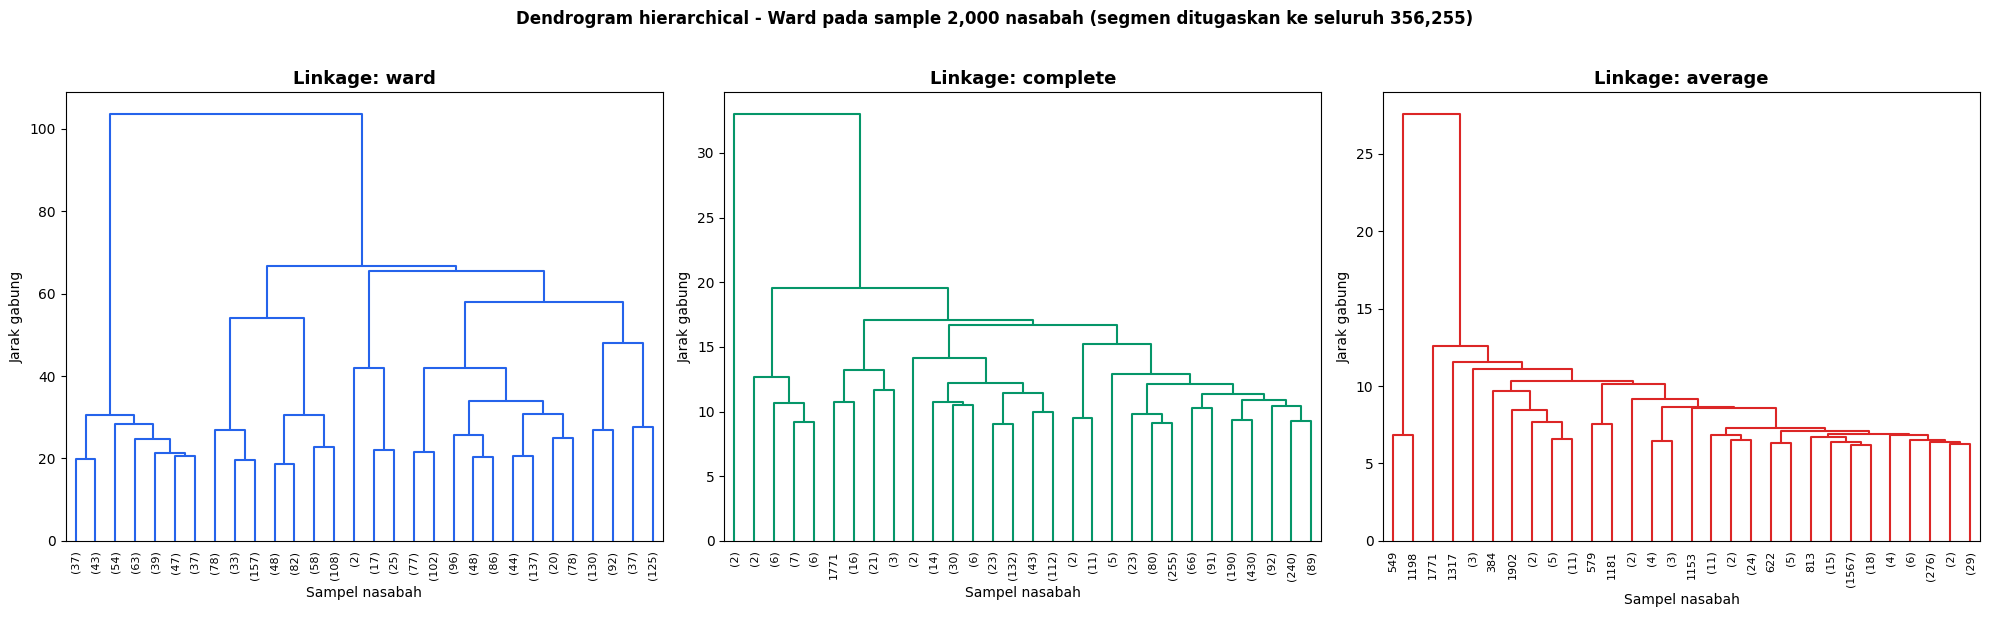

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2563EB', '#059669', '#DC2626']
for ax, method, color in zip(axes, linkage_methods, colors):
    dendrogram(linkage_results[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0, above_threshold_color=color)
    ax.set_title(f'Linkage: {method}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sampel nasabah'); ax.set_ylabel('Jarak gabung')
plt.suptitle(f'Dendrogram hierarchical - Ward pada sample {len(subcenters):,} nasabah (segmen ditugaskan ke seluruh {len(X_cluster):,})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cluster maps in 2D

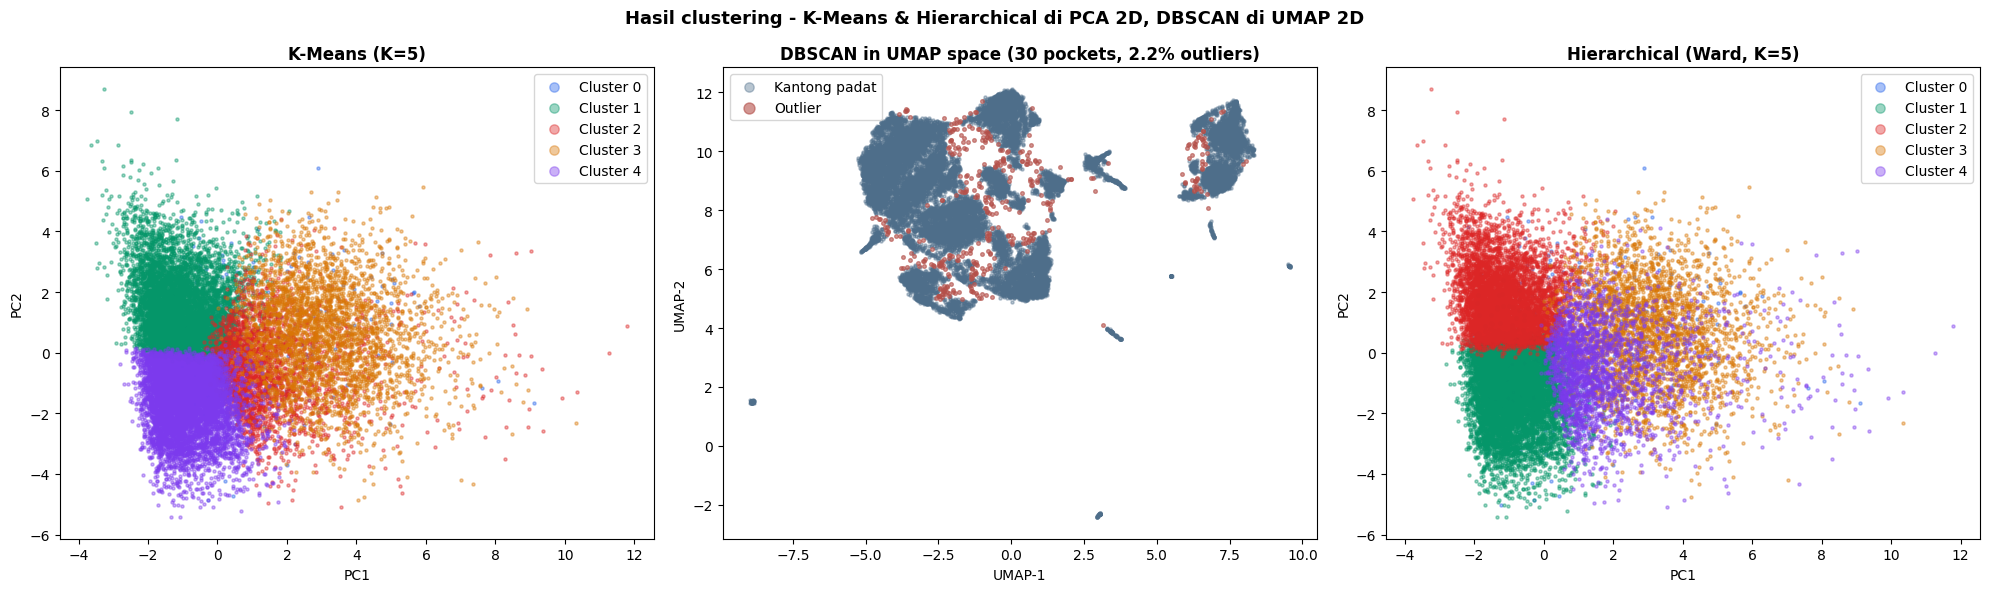

In [10]:
VIZ = 20000
rng4 = np.random.default_rng(RANDOM_SEED)
viz_idx = rng4.choice(len(X_2d), size=VIZ, replace=False)
COLORS = ['#2563EB', '#059669', '#DC2626', '#D97706', '#7C3AED']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cid in range(K_OPTIMAL):
    mask = kmeans_labels[viz_idx] == cid
    axes[0].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[0].set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

viz_db_n = min(VIZ, len(dbscan_idx))
db_lbl = dbscan_labels[:viz_db_n]
noise_mask = db_lbl == -1
axes[1].scatter(X_umap[:viz_db_n][~noise_mask, 0], X_umap[:viz_db_n][~noise_mask, 1],
                c='#4E6E8A', label='Kantong padat', alpha=0.4, s=5)
axes[1].scatter(X_umap[:viz_db_n][noise_mask, 0], X_umap[:viz_db_n][noise_mask, 1],
                c='#B4504A', label='Outlier', alpha=0.6, s=7)
axes[1].set_title(f'DBSCAN in UMAP space ({n_clusters_db} pockets, {pct_out:.1f}% outliers)', fontweight='bold')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=3)

for cid in range(K_OPTIMAL):
    mask = hier_labels[viz_idx] == cid
    axes[2].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[2].set_title(f'Hierarchical (Ward, K={K_OPTIMAL})', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=3)

plt.suptitle('Hasil clustering - K-Means & Hierarchical di PCA 2D, DBSCAN di UMAP 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save the cluster labels

In [11]:
labels_df = pd.DataFrame({
    'ROW_ID': np.arange(len(X_cluster)),
    'CLUSTER_KMEANS': kmeans_labels,
    'CLUSTER_HIER': hier_labels,
})
if 'SK_ID_CURR' in df.columns:
    labels_df.insert(1, 'SK_ID_CURR', df['SK_ID_CURR'].values)
labels_df['CLUSTER_DBSCAN'] = np.nan
labels_df.loc[dbscan_idx, 'CLUSTER_DBSCAN'] = dbscan_labels.astype(float)
labels_df['IS_OUTLIER'] = (labels_df['CLUSTER_DBSCAN'] == -1).astype('Int8')

labels_df.to_csv(OUT_DIR / 'cluster_labels.csv', index=False)
labels_df.to_csv(PROJECT_ROOT / 'datasets/final/cluster_labels.csv', index=False)
print(f'Saved cluster_labels.csv to:')
print(f'  {OUT_DIR / "cluster_labels.csv"}')
print(f'  {PROJECT_ROOT / "datasets/final/cluster_labels.csv"}  (for Phase 3 and 4)')
# Export a downsampled 2D projection for the Phase 5 dashboard
viz_export = pd.DataFrame({
    'PC1': X_2d[viz_idx, 0],
    'PC2': X_2d[viz_idx, 1],
    'CLUSTER_KMEANS': kmeans_labels[viz_idx],
})
viz_export.to_csv(OUT_DIR / 'cluster_viz_sample.csv', index=False)
print(f'Saved cluster_viz_sample.csv ({len(viz_export):,} rows for the dashboard)')
labels_df.head()

Saved cluster_labels.csv to:
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\cluster_labels.csv
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\datasets\final\cluster_labels.csv  (for Phase 3 and 4)
Saved cluster_viz_sample.csv (20,000 rows for the dashboard)


,ROW_ID,SK_ID_CURR,CLUSTER_KMEANS,CLUSTER_HIER,CLUSTER_DBSCAN,IS_OUTLIER
0,0,100002,4,1,11.0,0
1,1,100003,1,2,NaN,0
2,2,100004,4,1,NaN,0
3,3,100006,4,1,NaN,0
4,4,100007,4,2,2.0,0


## 9. Cluster profiling: what makes each segment different

For every feature we take its mean per cluster and compare it to the global mean, scaled by the global standard deviation. The result reads as "standard deviations from average, times 100", so the features with the largest absolute deviation are the ones that set a cluster apart.

In [12]:
TOP_N = 10
df_prof = pd.concat([df.reset_index(drop=True), labels_df[['CLUSTER_KMEANS']].reset_index(drop=True)], axis=1)
feat_cols = [c for c in df_prof.columns if c not in ['SK_ID_CURR', 'CLUSTER_KMEANS'] and pd.api.types.is_numeric_dtype(df_prof[c])]

profiles = df_prof.groupby('CLUSTER_KMEANS')[feat_cols].mean()
global_mean = df_prof[feat_cols].mean()
global_std = df_prof[feat_cols].std().replace(0, np.nan)
rel_diff = profiles.sub(global_mean).div(global_std) * 100

profiles.to_csv(OUT_DIR / 'cluster_profiles.csv')
print(f'Saved cluster_profiles.csv ({profiles.shape[0]} clusters x {profiles.shape[1]} features)')

summary_rows = []
top_features = {}
for cid in rel_diff.index:
    row = rel_diff.loc[cid].abs().sort_values(ascending=False)
    top_cols = row.head(TOP_N).index.tolist()
    top_df = pd.DataFrame({
        'fitur': top_cols,
        'rel_diff_pct': rel_diff.loc[cid, top_cols].values,
        'arah': ['ABOVE' if v > 0 else 'BELOW' for v in rel_diff.loc[cid, top_cols].values],
    }).sort_values('rel_diff_pct', key=abs, ascending=False)
    top_features[cid] = top_df
    for _, r in top_df.iterrows():
        summary_rows.append({'cluster_id': cid, 'fitur': r['fitur'], 'rel_diff_pct': round(r['rel_diff_pct'], 2), 'arah': r['arah']})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'cluster_summary.csv', index=False)
print(f'Saved cluster_summary.csv')

for cid in sorted(top_features.keys()):
    n = (labels_df['CLUSTER_KMEANS'] == cid).sum()
    pct = n / len(labels_df) * 100
    print(f'\n{"="*70}\nCLUSTER {cid} - {n:,} applicants ({pct:.1f}%)\n{"-"*70}')
    for _, r in top_features[cid].iterrows():
        arrow = 'up' if r['arah'] == 'ABOVE' else 'down'
        print(f'  {r["fitur"]:42s} {r["rel_diff_pct"]:>+7.1f}%  {arrow} {r["arah"]}')

Saved cluster_profiles.csv (5 clusters x 47 features)


Saved cluster_summary.csv

CLUSTER 0 - 3,582 applicants (1.0%)
----------------------------------------------------------------------
  INST_DPD_MAX                                +692.7%  up ABOVE
  INST_SEVERE_LATE_RATIO                      +549.1%  up ABOVE
  INST_DPD_MEAN                               +473.4%  up ABOVE
  POS_SK_DPD_MEAN                             +420.6%  up ABOVE
  CC_SK_DPD_MEAN                              +212.9%  up ABOVE
  INST_LATE_RATIO                             +190.4%  up ABOVE
  POS_MONTHS_COUNT                             +93.0%  up ABOVE
  BUREAU_BB_SEVERE_DPD_MEAN                    +49.1%  up ABOVE
  BUREAU_BB_DPD_RATIO_MEAN                     +40.8%  up ABOVE
  CC_MONTHS_COUNT                              +37.6%  up ABOVE

CLUSTER 1 - 125,071 applicants (35.1%)
----------------------------------------------------------------------
  AMT_CREDIT                                   +83.3%  up ABOVE
  CREDIT_TO_INCOME                             +74.

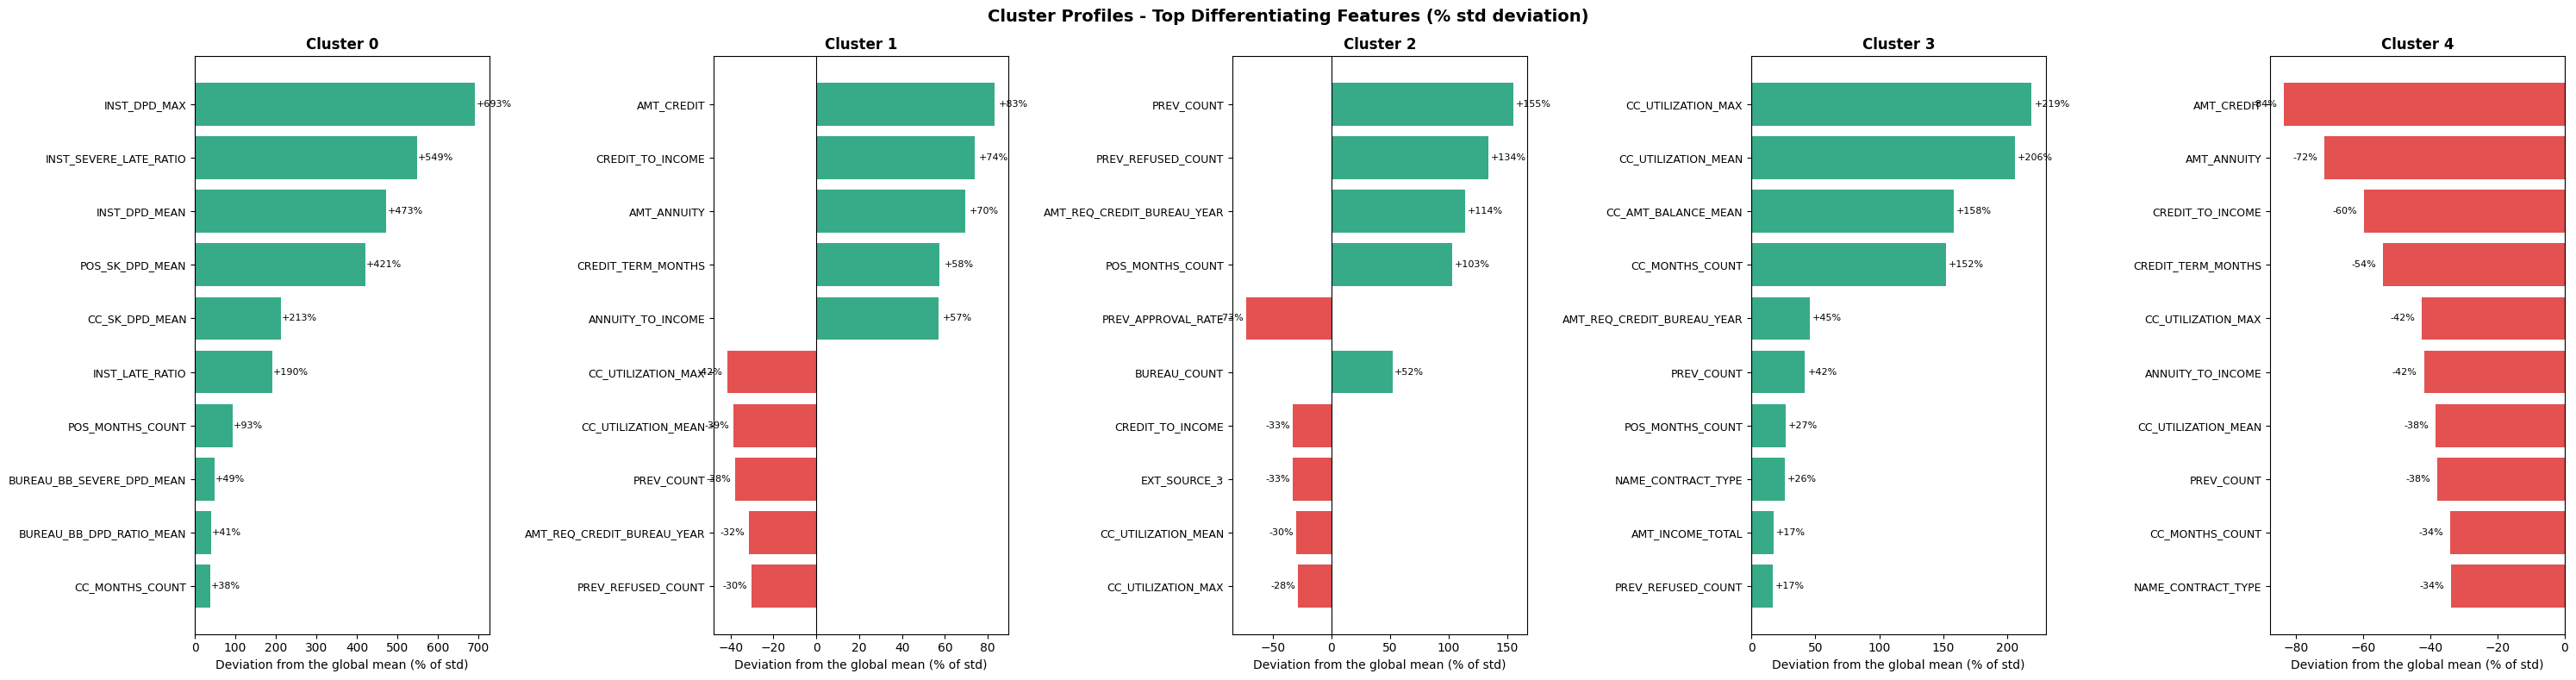

In [13]:
n_clusters = len(top_features)
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 8))
if n_clusters == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(top_features.keys())):
    tdf = top_features[cid].head(TOP_N)
    values = tdf['rel_diff_pct'].values
    labels = tdf['fitur'].values
    colors_bar = ['#059669' if v > 0 else '#DC2626' for v in values]
    bars = ax.barh(range(len(values)), values, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Deviation from the global mean (% of std)')
    ax.set_title(f'Cluster {cid}', fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        x = val + (2 if val >= 0 else -2)
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=8, ha='left' if val >= 0 else 'right')
plt.suptitle('Cluster Profiles - Top Differentiating Features (% std deviation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business interpretation and segment naming

A human reads the top differentiating features of each cluster and gives it a business name, a risk level, and a short recommendation. The algorithm only finds the grouping; turning it into something a bank can act on is the analyst's job. The names and sizes are saved to `cluster_names.csv` so every later phase reads them rather than hard-coding a mapping that shifts between runs.

In [14]:
def name_cluster(cid, tdf):
    """Pick a cluster name from its top features. Can be overridden by hand."""
    top = tdf.head(5)
    feats = ' '.join(top['fitur'].values)
    dpd_signal = top[(top['fitur'].str.contains('DPD|LATE')) & (top['rel_diff_pct'] > 100)]
    cc_high = top[(top['fitur'].str.contains('CC_UTILIZATION')) & (top['rel_diff_pct'] > 100)]
    credit_high = (top[top['fitur']=='AMT_CREDIT']['rel_diff_pct'].sum() > 30)
    credit_low = (top[top['fitur']=='AMT_CREDIT']['rel_diff_pct'].sum() < -30)
    prev_high = (top[top['fitur']=='PREV_COUNT']['rel_diff_pct'].sum() > 30)
    if len(dpd_signal) >= 2:
        return ('Troubled Borrower', 'Chronic defaulter, extreme risk profile', 'Very high')
    if len(cc_high) >= 2:
        return ('Intensive Card User', 'Revolving-credit dependent', 'Medium-high')
    if credit_high and not prev_high:
        return ('Ambitious Borrower', 'Large loan, high debt-to-income', 'Medium')
    if credit_low:
        return ('Minimal Borrower', 'Simple borrower, low income and small loan', 'Low-medium')
    if prev_high:
        return ('Active Veteran', 'High income, often rejected', 'Medium-high')
    return (f'Cluster {cid}', f'Segment {cid}', 'Medium')

RECS = {
    'Troubled Borrower': 'Decline new applications or require strict collateral. Offer restructuring to existing customers. Run intensive collection. Flag as priority high-risk monitoring.',
    'Intensive Card User': 'Monitor card utilisation regularly. Offer debt consolidation. Hold limit increases until utilisation falls below 70 percent.',
    'Ambitious Borrower': 'Verify income stability before approval. Ideal for mortgages and vehicle loans. Stress-test ability to pay if income drops 20 to 30 percent. Consider life or health insurance as a condition.',
    'Minimal Borrower': 'An ideal segment for micro-credit or small multipurpose loans. Prioritise financial education and inclusion. Light monitoring is enough.',
    'Active Veteran': 'Review the history of rejections. Suited to secured credit (mortgage) given the long relationship. Verify the debt-to-income ratio tightly.',
}

cluster_meta = {}
for cid, tdf in top_features.items():
    nama, nama_lengkap, risiko = name_cluster(cid, tdf)
    cluster_meta[cid] = {
        'nama': nama,
        'nama_lengkap': nama_lengkap,
        'profil_risiko': risiko,
        'rekomendasi': RECS.get(nama, 'Evaluate case by case.'),
        'karakteristik': [
            f"{r['fitur']} {r['rel_diff_pct']:+.1f}% ({r['arah']})"
            for _, r in tdf.iterrows()
        ],
    }
    print(f'Cluster {cid}: "{nama}" - Risk: {risiko}')

# Persist the cluster_id to business-name mapping for Phase 3/4/5.
# The label order is NOT deterministic between runs, so downstream MUST read
# this artefact rather than hard-coding cluster names.
SLUG_BY_NAME = {
    'Active Veteran': 'veteran', 'Minimal Borrower': 'minimal',
    'Intensive Card User': 'cc_intensif', 'Ambitious Borrower': 'ambisius',
    'Troubled Borrower': 'bermasalah',
}
names_df = pd.DataFrame([
    {'cluster_id': cid,
     'nama': m['nama'],
     'slug': SLUG_BY_NAME.get(m['nama'], f'c{cid}'),
     'profil_risiko': m['profil_risiko'],
     'n_applicants': int((labels_df['CLUSTER_KMEANS'] == cid).sum())}
    for cid, m in sorted(cluster_meta.items())
])
names_df.to_csv(OUT_DIR / 'cluster_names.csv', index=False)
names_df.to_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv', index=False)
print('\nSaved cluster_names.csv (results + datasets/final):')
print(names_df.to_string(index=False))

Cluster 0: "Troubled Borrower" - Risk: Very high
Cluster 1: "Ambitious Borrower" - Risk: Medium
Cluster 2: "Active Veteran" - Risk: Medium-high
Cluster 3: "Intensive Card User" - Risk: Medium-high
Cluster 4: "Minimal Borrower" - Risk: Low-medium

Saved cluster_names.csv (results + datasets/final):
 cluster_id                nama        slug profil_risiko  n_applicants
          0   Troubled Borrower  bermasalah     Very high          3582
          1  Ambitious Borrower    ambisius        Medium        125071
          2      Active Veteran     veteran   Medium-high         46905
          3 Intensive Card User cc_intensif   Medium-high         54215
          4    Minimal Borrower     minimal    Low-medium        126482


---
Phase 2 done. The artefacts are in `results/phase2_clustering/`, and `datasets/final/cluster_labels.csv` carries the segment assignments forward to Phase 3 and Phase 4.